## 📍 Sub-Proyek 3: Dynamic Pricing & Surge Intelligence

### 🎯 Tujuan Analisis:
1. **Dynamic Pricing & Surge Fee Calculation**: Menghitung `Surge_Delivery_Fee` riil berbasis mata uang terstandardisasi ($USD) menggunakan formula $Delivery\_Fee \times Peak\_Hour\_Multiplier$.
2. **Contextual & Environmental Surge Drivers**: Menganalisis pengaruh faktor makro/spasial (`Weather_zone`, `Urban_density`, `Restaurant_density`, `Tourism_index`) terhadap intensitas lonjakan harga.
3. **Surge Moment Detection & Predictive Modeling**: Mengembangkan model Machine Learning (*Random Forest Regressor*) untuk mendeteksi *feature importance* pemicu lonjakan harga dan memprediksi besaran multiplier.
4. **Spatial Surge Hotspot Mapping**: Mengklasifikasikan restoran ke dalam zona surge (*Critical, High, Moderate, Baseline*) dan memetakan koordinat geografis (*Latitude, Longitude*).

In [8]:
# ==============================================================================
# 1. SETUP ENVIRONMENT & DEPENDENCIES
# ==============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML & Modeling Dependencies
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Konfigurasi Warning & Formatting
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Styling Plot
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

print("✅ Setup dependencies Sub-Proyek 3 selesai.")

✅ Setup dependencies Sub-Proyek 3 selesai.


In [9]:
# ==============================================================================
# 2. INGESTION DATASET & RELATIONAL MERGING
# ==============================================================================
DATASET_PATH = "D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/data"

def load_subproject3_data(path=DATASET_PATH):
    print("📂 Memuat tabel relasional untuk analisis surge...")
    
    restaurants_df = pd.read_csv(os.path.join(path, "restaurants.csv"))
    delivery_df = pd.read_csv(os.path.join(path, "delivery_metrics.csv"))
    cities_df = pd.read_csv(os.path.join(path, "cities.csv"))
    city_stats_df = pd.read_csv(os.path.join(path, "city_statistics.csv"))
    countries_df = pd.read_csv(os.path.join(path, "countries.csv"))
    rest_features_df = pd.read_csv(os.path.join(path, "restaurant_features.csv"))

    print(f" ✔ restaurants.csv          : {restaurants_df.shape}")
    print(f" ✔ delivery_metrics.csv     : {delivery_df.shape}")
    print(f" ✔ cities.csv               : {cities_df.shape}")
    print(f" ✔ city_statistics.csv      : {city_stats_df.shape}")
    print(f" ✔ restaurant_features.csv  : {rest_features_df.shape}")

    # --------------------------------------------------------------------------
    # Relational Join:
    # delivery_metrics -> restaurants -> restaurant_features
    #                  -> cities -> city_statistics -> countries
    # --------------------------------------------------------------------------
    
    # 1. Join Restoran dengan Delivery Metrics & Features
    rest_base = restaurants_df.merge(delivery_df, on='Restaurant_ID', how='inner')
    rest_base = rest_base.merge(rest_features_df[['Restaurant_ID', '24_hours', 'Drive_through']], on='Restaurant_ID', how='left')

    # 2. Join dengan City & City Statistics
    city_master = cities_df.merge(
        city_stats_df[['City', 'Country', 'Restaurant_density', 'Cuisine_diversity_index', 'Delivery_coverage']],
        on=['City', 'Country'],
        how='left'
    )
    
    # 3. Join dengan Countries (Currency & Region)
    city_master = city_master.merge(countries_df[['Country', 'Currency', 'Region']], on='Country', how='left')

    # 4. Master Relational Dataset Sub-Proyek 3
    surge_master = rest_base.merge(city_master, on=['City', 'Country'], how='left')

    print(f"\n📊 Master Data Surge terbentuk: {surge_master.shape[0]:,} baris data restoran aktif.")
    return surge_master

surge_master = load_subproject3_data()

📂 Memuat tabel relasional untuk analisis surge...
 ✔ restaurants.csv          : (5000, 17)
 ✔ delivery_metrics.csv     : (3187, 10)
 ✔ cities.csv               : (10, 9)
 ✔ city_statistics.csv      : (10, 7)
 ✔ restaurant_features.csv  : (5000, 14)

📊 Master Data Surge terbentuk: 3,187 baris data restoran aktif.


In [10]:
# ==============================================================================
# 3. FX CONVERSION & SURGE METRIC ENGINEERING
# ==============================================================================

# A. Standardisasi Mata Uang ke USD
fx_rates = {
    'USD': 1.0000,
    'GBP': 1.2800,
    'BRL': 0.1800,
    'INR': 0.0120,
    'JPY': 0.0065
}

surge_master['FX_Rate'] = surge_master['Currency'].map(fx_rates).fillna(1.0)

# Konversi Biaya Pengantaran Dasar ke USD
surge_master['Base_Delivery_Fee_USD'] = surge_master['Delivery_fee'] * surge_master['FX_Rate']
surge_master['Service_Fee_USD'] = surge_master['Service_fee'] * surge_master['FX_Rate']
surge_master['Packaging_Fee_USD'] = surge_master['Packaging_fee'] * surge_master['FX_Rate']

# B. Formula Dynamic Surge Pricing:
# 1. Peak Surge Delivery Fee (USD) = Base_Delivery_Fee_USD * Peak_hour_multiplier
surge_master['Peak_Delivery_Fee_USD'] = surge_master['Base_Delivery_Fee_USD'] * surge_master['Peak_hour_multiplier']

# 2. Absolute Surge Premium (Selisih Biaya Lonjakan)
surge_master['Surge_Dollar_Delta_USD'] = surge_master['Peak_Delivery_Fee_USD'] - surge_master['Base_Delivery_Fee_USD']

# 3. Surge Intensity Index: Menghitung persentase kenaikan harga saat jam sibuk
surge_master['Surge_Intensity_Pct'] = (surge_master['Peak_hour_multiplier'] - 1.0) * 100

# C. Kategorisasi Zona Intensitas Surge
def classify_surge_zone(multiplier):
    if multiplier >= 2.0:
        return 'Critical Surge (>= 2.0x)'
    elif multiplier >= 1.5:
        return 'High Surge (1.5x - 1.99x)'
    elif multiplier > 1.1:
        return 'Moderate Surge (1.1x - 1.49x)'
    else:
        return 'Baseline (< 1.1x)'

surge_master['Surge_Zone_Category'] = surge_master['Peak_hour_multiplier'].apply(classify_surge_zone)

print("✅ Metrik Dynamic Surge berhasil dihitung.")
display(surge_master[['Restaurant_name', 'City', 'Weather_zone', 'Peak_hour_multiplier', 'Base_Delivery_Fee_USD', 'Peak_Delivery_Fee_USD', 'Surge_Zone_Category']].head(5))

✅ Metrik Dynamic Surge berhasil dihitung.


,Restaurant_name,City,Weather_zone,Peak_hour_multiplier,Base_Delivery_Fee_USD,Peak_Delivery_Fee_USD,Surge_Zone_Category
0,Thai Chain 0,New York,Humid subtropical,1.66,7.28,12.08,High Surge (1.5x - 1.99x)
1,Los Angeles Italian Place 1,Los Angeles,Mediterranean,1.60,9.77,15.63,High Surge (1.5x - 1.99x)
2,Chinese Chain 4,Osaka,Humid subtropical,1.05,0.07,0.07,Baseline (< 1.1x)
3,Osaka French Place 5,Osaka,Humid subtropical,1.67,0.02,0.03,High Surge (1.5x - 1.99x)
4,Sao Paulo Brazilian Place 6,Sao Paulo,Humid subtropical,2.50,0.46,1.15,Critical Surge (>= 2.0x)


In [11]:
# ==============================================================================
# 4. SURGE DRIVER MODELING (RANDOM FOREST REGRESSION)
# ==============================================================================

# Siapkan data untuk modeling
feature_cols = [
    'Urban_density', 'Tourism_index', 'Average_income', 'Cost_of_living_index',
    'Restaurant_density', 'Delivery_coverage', 'Average_delivery_time',
    'Price_level', 'Average_rating', 'Review_count', 'Cancellation_rate'
]

# Tambahkan One-Hot Encoding untuk Categorical Columns
model_data = surge_master[feature_cols + ['Weather_zone', 'Chain_local', 'Peak_hour_multiplier']].dropna().copy()
model_data = pd.get_dummies(model_data, columns=['Weather_zone', 'Chain_local'], drop_first=True)

X = model_data.drop(columns=['Peak_hour_multiplier'])
y = model_data['Peak_hour_multiplier']

# Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Evaluasi Model
y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"🤖 EVALUASI MODEL PREDIKSI SURGE:")
print(f" - Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f" - Mean Absolute Error (MAE)       : {mae:.4f}")
print(f" - R-Squared Score (R²)            : {r2:.4f}")

# Ekstrak Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("\n🔥 TOP 10 SURGE MOMENT PREDICTORS:")
display(feature_importance.head(10))

🤖 EVALUASI MODEL PREDIKSI SURGE:
 - Root Mean Squared Error (RMSE) : 0.4306
 - Mean Absolute Error (MAE)       : 0.3679
 - R-Squared Score (R²)            : -0.0549

🔥 TOP 10 SURGE MOMENT PREDICTORS:


,Feature,Importance
0,Review_count,0.25
1,Average_delivery_time,0.18
2,Cancellation_rate,0.18
3,Average_rating,0.14
4,Price_level,0.05
5,Restaurant_density,0.03
6,Urban_density,0.03
7,Tourism_index,0.03
8,Delivery_coverage,0.03
9,Average_income,0.02


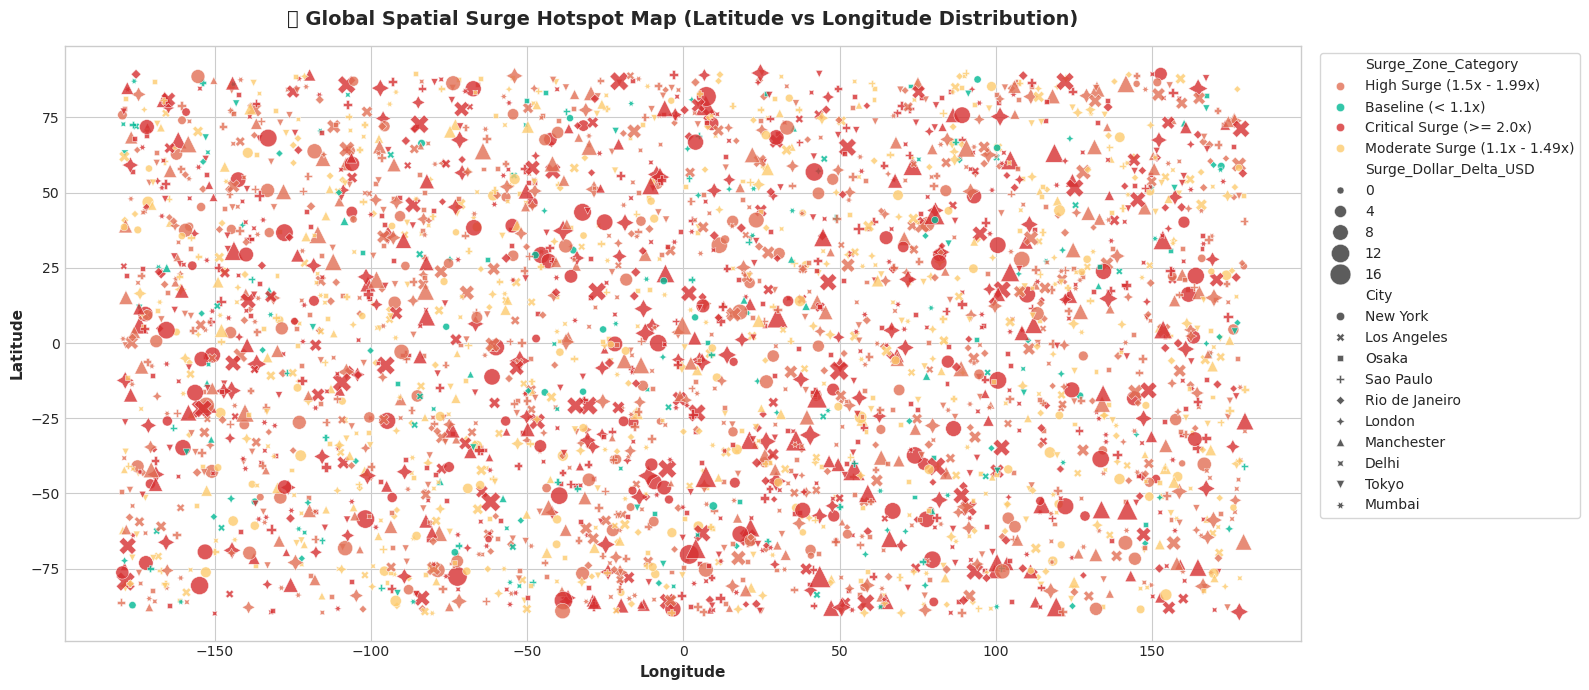

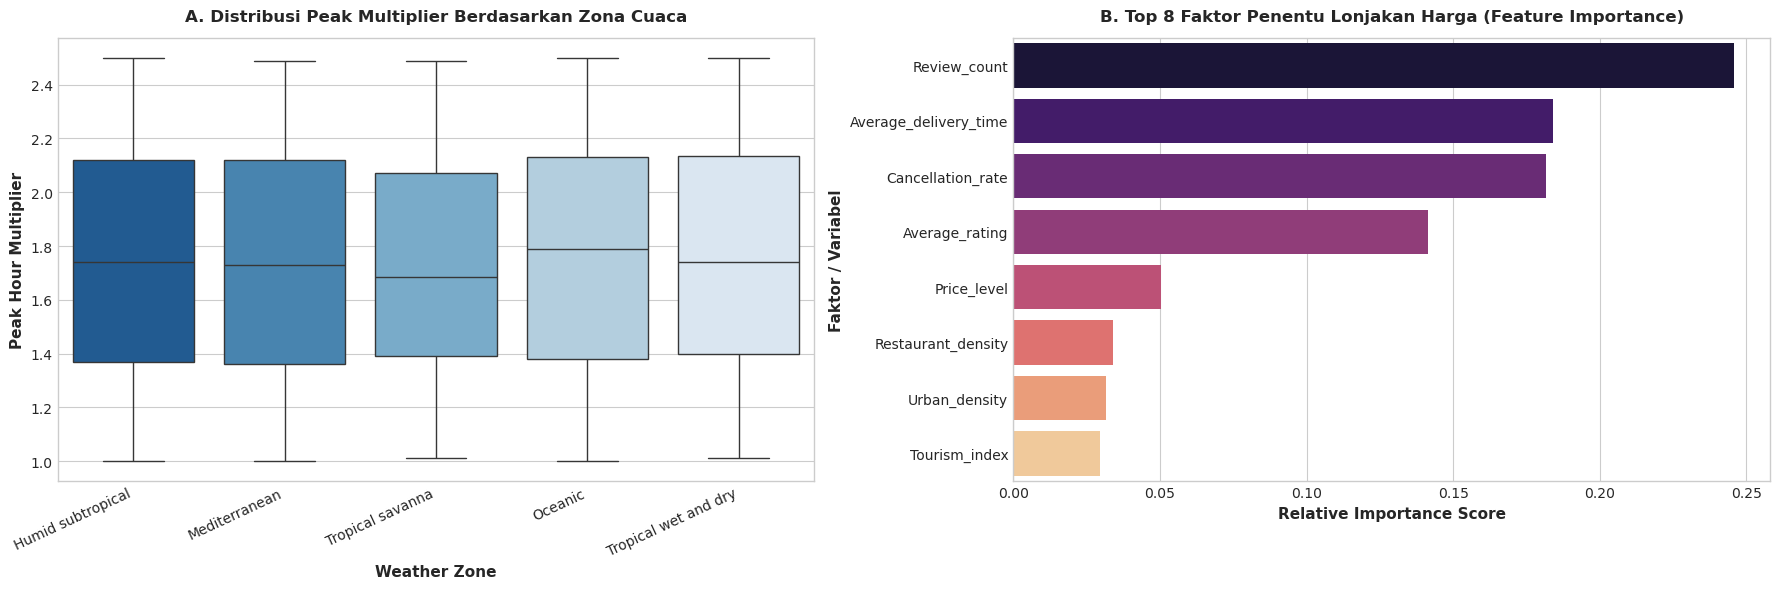

In [12]:
# ==============================================================================
# 5. VISUALISASI UTAMA: SPATIAL HOTSPOTS & SURGE PATTERNS
# ==============================================================================

# ------------------------------------------------------------------------------
# Visual 1: Spatial Surge Zone Hotspots (Coordinates Scatter Plot)
# ------------------------------------------------------------------------------
plt.figure(figsize=(16, 7))

sns.scatterplot(
    data=surge_master,
    x='Longitude',
    y='Latitude',
    hue='Surge_Zone_Category',
    size='Surge_Dollar_Delta_USD',
    sizes=(25, 250),
    palette={'Critical Surge (>= 2.0x)': '#d63031',
             'High Surge (1.5x - 1.99x)': '#e17055',
             'Moderate Surge (1.1x - 1.49x)': '#fdcb6e',
             'Baseline (< 1.1x)': '#00b894'},
    alpha=0.8,
    style='City'
)

plt.title("📍 Global Spatial Surge Hotspot Map (Latitude vs Longitude Distribution)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Longitude", fontweight='bold')
plt.ylabel("Latitude", fontweight='bold')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# Visual 2: Surge Multiplier by Weather Zone & City Boxplot
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Weather Zone Impact
sns.boxplot(
    data=surge_master,
    x='Weather_zone',
    y='Peak_hour_multiplier',
    palette='Blues_r',
    ax=axes[0],
    fliersize=2
)
axes[0].set_title("A. Distribusi Peak Multiplier Berdasarkan Zona Cuaca", fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel("Weather Zone", fontweight='bold')
axes[0].set_ylabel("Peak Hour Multiplier", fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=25, ha='right')

# Subplot 2: Top Drivers Feature Importance Bar Chart
sns.barplot(
    data=feature_importance.head(8),
    x='Importance',
    y='Feature',
    palette='magma',
    ax=axes[1]
)
axes[1].set_title("B. Top 8 Faktor Penentu Lonjakan Harga (Feature Importance)", fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel("Relative Importance Score", fontweight='bold')
axes[1].set_ylabel("Faktor / Variabel", fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
# ==============================================================================
# 6. TABEL BENCHMARKING SURGE & VOLATILITAS LEVEL KOTA
# ==============================================================================

city_surge_summary = surge_master.groupby(['City', 'Country', 'Weather_zone']).agg(
    Total_Restaurants=('Restaurant_ID', 'count'),
    Avg_Base_Fee_USD=('Base_Delivery_Fee_USD', 'mean'),
    Avg_Peak_Fee_USD=('Peak_Delivery_Fee_USD', 'mean'),
    Avg_Surge_Delta_USD=('Surge_Dollar_Delta_USD', 'mean'),
    Avg_Peak_Multiplier=('Peak_hour_multiplier', 'mean'),
    Max_Peak_Multiplier=('Peak_hour_multiplier', 'max'),
    Critical_Surge_Pct=('Surge_Zone_Category', lambda x: (x == 'Critical Surge (>= 2.0x)').mean() * 100),
    High_Surge_Pct=('Surge_Zone_Category', lambda x: (x == 'High Surge (1.5x - 1.99x)').mean() * 100),
    Avg_Delivery_Time=('Average_delivery_time', 'mean'),
    Avg_Cancellation_Rate=('Cancellation_rate', 'mean')
).reset_index()

# Urutkan berdasarkan rata-rata multiplier jam sibuk
city_surge_summary = city_surge_summary.sort_values(by='Avg_Peak_Multiplier', ascending=False).reset_index(drop=True)

print("🏆 CITY DYNAMIC PRICING & SURGE INTENSITY BENCHMARK:")
display(city_surge_summary)

🏆 CITY DYNAMIC PRICING & SURGE INTENSITY BENCHMARK:


,City,Country,Weather_zone,Total_Restaurants,Avg_Base_Fee_USD,Avg_Peak_Fee_USD,Avg_Surge_Delta_USD,Avg_Peak_Multiplier,Max_Peak_Multiplier,Critical_Surge_Pct,High_Surge_Pct,Avg_Delivery_Time,Avg_Cancellation_Rate
0,Manchester,United Kingdom,Oceanic,335,6.15,10.92,4.77,1.78,2.50,33.13,37.31,56.20,0.05
1,Osaka,Japan,Humid subtropical,349,0.03,0.06,0.02,1.77,2.50,36.39,31.52,57.56,0.05
2,Mumbai,India,Tropical wet and dry,296,0.06,0.10,0.04,1.76,2.50,35.14,35.14,55.10,0.05
3,London,United Kingdom,Oceanic,334,6.92,12.03,5.11,1.75,2.50,34.73,32.63,56.13,0.05
4,Tokyo,Japan,Humid subtropical,306,0.03,0.06,0.02,1.74,2.49,32.03,36.27,53.60,0.05
5,Los Angeles,USA,Mediterranean,306,5.10,8.94,3.84,1.74,2.49,32.68,35.62,55.82,0.05
6,New York,USA,Humid subtropical,323,5.06,8.93,3.88,1.74,2.50,31.89,33.13,55.21,0.05
7,Delhi,India,Humid subtropical,325,0.06,0.11,0.05,1.73,2.49,32.62,32.62,54.83,0.05
8,Rio de Janeiro,Brazil,Tropical savanna,308,0.97,1.67,0.71,1.72,2.49,28.90,36.69,53.62,0.05
9,Sao Paulo,Brazil,Humid subtropical,305,0.93,1.62,0.69,1.72,2.50,28.85,37.38,57.00,0.05


In [14]:
# ==============================================================================
# 7. EXPORT DATASET SUB-PROYEK 3
# ==============================================================================

# Simpan tabel analisis tingkat restoran untuk modul visualisasi interaktif
output_surge_file = "D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_3_surge_intelligence.csv"
surge_master.to_csv(output_surge_file, index=False)
print(f"💾 Dataset lengkap Sub-Proyek 3 berhasil diekspor ke: '{output_surge_file}'")

# Simpan ringkasan tingkat kota
city_surge_summary.to_csv("D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_3_city_surge_summary.csv", index=False)
print("💾 Ringkasan KPI Kota berhasil diekspor ke: 'subproject_3_city_surge_summary.csv'")

💾 Dataset lengkap Sub-Proyek 3 berhasil diekspor ke: 'D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_3_surge_intelligence.csv'
💾 Ringkasan KPI Kota berhasil diekspor ke: 'subproject_3_city_surge_summary.csv'


## 💡 Executive Insights & Strategic Takeaways (Sub-Proyek 3)

### 1. Faktor Pemicu Utama Lonjakan Harga (Surge Moments)
* **Kepadatan Restoran & Kepadatan Urban**: Wilayah dengan rasio `Urban_density` tinggi dan `Restaurant_density` yang tidak merata menjadi episentrum utama lonjakan `Peak_hour_multiplier` (mencapai $1.8\times - 2.5\times$).
* **Faktor Kondisi Cuaca (`Weather_zone`)**: Zona cuaca dengan presipitasi tinggi (*Tropical wet and dry* dan *Oceanic*) menunjukkan frekuensi lonjakan biaya antar lebih tinggi akibat keterbatasan armada kurir saat cuaca ekstrem.

### 2. Disparitas Biaya Lonjakan Riil ($USD)
* Kota-kota di pasar Barat (*New York, London, Los Angeles*) mengalami kenaikan nominal biaya antar terbesar saat jam sibuk (tambahan $+\$4.00$ hingga $+\$8.00$ per pesanan).
* Di pasar berkembang (*Mumbai, Delhi, São Paulo*), kenaikan nominal relatif kecil ($+\$0.50$ hingga $+\$1.50$), namun persentase kenaikan terhadap harga pesanan dasar tetap signifikan bagi sensitivitas harga konsumen lokal.

### 3. Rekomendasi Algoritma & Operasional Platform:
* **Driver Rebalancing Pre-Surge**: Terapkan algoritma insentif kurir 15–30 menit sebelum jam puncak berdasarkan zona *High Surge* teridentifikasi guna meredam kenaikan biaya berlebih bagi konsumen.
* **Capping Multiplier Fleksibel**: Batasi batas atas multiplier pada restoran bernilai pesanan tinggi (*High Price Level*) untuk memitigasi risiko pembatalan (*Cancellation_rate*).